In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.utils.tools import seed_everything
import torch
from src.utils.constants import DEVICE



EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [13]:
targets=['bs_label','bf_label']
with open('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_dim256_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"benchmarks/burstformer_para_tune/checkpoints/{eid}.{fold}.bs_bf_para.tune.dim256.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                pearsonr = ckpt[f"{target}_val_auc"]
                line = [eid,str(fold),str(pearsonr),target]
                w.write(','.join(line) + '\n')


targets=['bs_label','bf_label']
with open('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"benchmarks/burstformer_para_tune/checkpoints/{eid}.{fold}.bs_bf_para.tune.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                pearsonr = ckpt[f"{target}_val_auc"]
                line = [eid,str(fold),str(pearsonr),target]
                w.write(','.join(line) + '\n')

In [14]:


data1 = pd.read_csv('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_indicators.csv')
data1['auc'] = data1['auc'] / 100
data1['dim'] = '64'


data2 = pd.read_csv('/Volumes/ExtremeSSD/BioStudy/CodeReview/burstformer/extra/results/bs_bf_para_indicators.csv')
data2['auc'] = data2['auc'] / 100
data2['dim'] = '128'

data3 = pd.read_csv('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_dim256_indicators.csv')
data3['auc'] = data3['auc'] / 100
data3['dim'] = '256'

data = pd.concat([data1,data2,data3],axis=0)

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_82280/300853204.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_82280/300853204.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


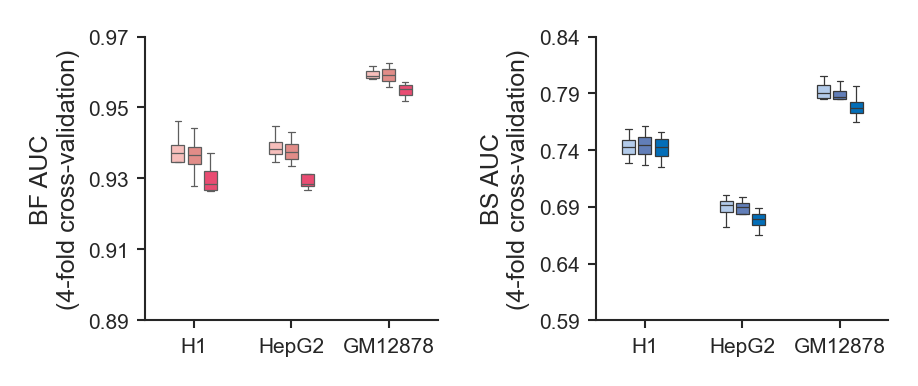

In [18]:



order = ['E003','E118','E116']
fig, ax = plt.subplots(1, 2, figsize=(8/2.54, 3.5/2.54))
palette = ['#F6BEBB',"#E18C88","#E94C72"]
sns.boxplot(data=data[data['target']=='bf_label'],y='auc',x='eid',hue='dim',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[0],saturation=1)


ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_ylim(bottom=0.89,top=0.97)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUC\n(4-fold cross-validation)',fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_yticks([i/100 for i in range(89, 98, 2)],labels=[i/100 for i in range(89, 98, 2)])


palette = ['#B3CBEA',"#627EB8","#036EB8"]
sns.boxplot(data=data[data['target']=='bs_label'],y='auc',x='eid',hue='dim', fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[1],saturation=1)

ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_ylabel(f'BS AUC\n(4-fold cross-validation)',fontsize=6)
ax[1].set_ylim(bottom=0.63,top=0.82)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_yticks([i/100 for i in range(59, 85, 5)],labels=[i/100 for i in range(59, 85, 5)])

plt.tight_layout()
# plt.savefig(f'benchmarks/burstformer_para_tune/figures/v6/Supplementary_Figure13C.eps', format='eps', bbox_inches='tight')
plt.show()

## binsize tuning

In [ ]:
targets=['bs_label','bf_label']
with open('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_binsize_indicators.csv','w') as w:
    line = ['eid','fold','auc','target','binsize']
    w.write(','.join(line) + '\n')
    for eid in ["E003","E116","E118"]:            
        for fold in [0, 1, 2, 3]:
            for binsize in ['100','200','500', '1000', '2000']:
                checkpoints = f"benchmarks/burstformer_para_tune/checkpoints/{eid}.{fold}.bs_bf_para.tune.binsize_{binsize}.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target, binsize]
                    w.write(','.join(line) + '\n')



/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_48432/333771257.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_48432/333771257.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], fontsize=6)


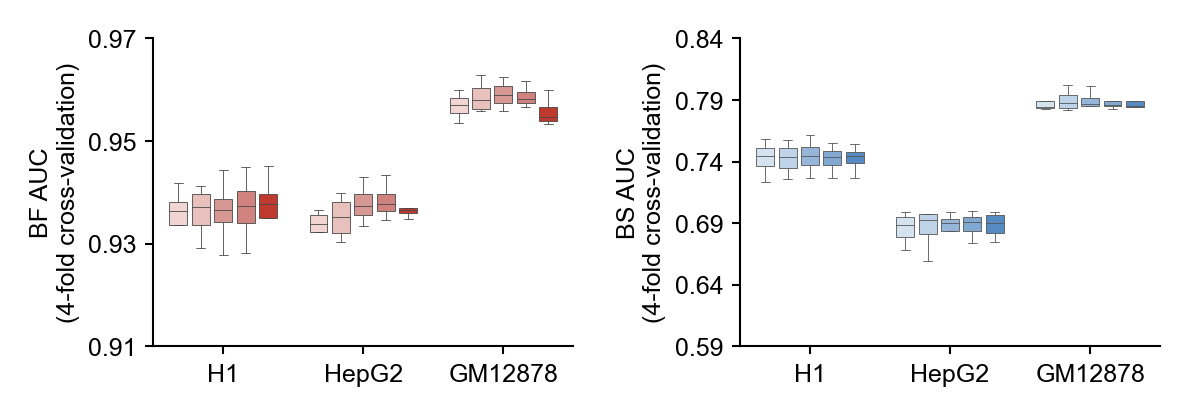

In [3]:
data = pd.read_csv('benchmarks/burstformer_para_tune/results/bs_bf_para_tune_binsize_indicators.csv')
data['auc'] = data['auc'] / 100

order = ['E003','E118','E116']
fig, ax = plt.subplots(1, 2, figsize=(10.3/2.54, 3.75/2.54))
palette = ['#F0D5D3','#E8C1BD','#D79792','#D0837E','#BF392F']


sns.boxplot(data=data[data['target']=='bf_label'],y='auc',x='eid',hue='binsize',fliersize=0, linewidth=0.2,order=order,
            gap=0.2,width=0.8,palette=palette,ax=ax[0],saturation=1)


ax[0].set_ylim(bottom=0.91,top=0.97)
ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUC\n(4-fold cross-validation)',fontsize=6)
# ax[0].set_ylabel(f'',fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], fontsize=6)
ax[0].set_yticks([i/100 for i in range(91, 98, 2)],labels=[i/100 for i in range(91, 98, 2)])


palette = ['#D5E2F0','#BFD3E8','#95B6D9','#81A8D1','#568AC2']
sns.boxplot(data=data[data['target']=='bs_label'],y='auc',x='eid',hue='binsize', fliersize=0, linewidth=0.2,order=order,
            gap=0.2,width=0.8,palette=palette,ax=ax[1],saturation=1)

ax[1].set_ylabel(f'BS AUC\n(4-fold cross-validation)',fontsize=6)
# ax[1].set_ylabel(f'',fontsize=6)
ax[1].set_ylim(bottom=0.63,top=0.82)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], fontsize=6)
ax[1].set_yticks([i/100 for i in range(59, 85, 5)],labels=[i/100 for i in range(59, 85, 5)])

plt.tight_layout()
plt.savefig(f'benchmarks/burstformer_para_tune/figures/v6/Supplementary_Figure7C.eps', format='eps', bbox_inches='tight')
plt.show()
